# ⏱️ sinc · Dirac · Energy · Clocks · Memory · Calculus · Identity

> Every EE and physics topic reduces to one of these: a basis function (sinc/Dirac),
> an energy principle (H/L), a timing constraint (setup/hold/jitter), or an identity (Euler/KVL).

| § | Topic | Core equation |
|---|---|---|
| §1 | sinc + Dirac delta | $\delta(t)$, $\text{sinc}(x)=\sin(\pi x)/(\pi x)$, sampling theorem |
| §2 | Classical energy notation | $H = T + V$, $L = T - V$, $S = \int L\,dt$ |
| §3 | EE timing + clocks | setup/hold slack, jitter PDF, PLL phase noise |
| §4 | Memory hierarchy | L1→DRAM latency, tRCD/CL/tRP, bandwidth roofline |
| §5 | Calculus resolution | $\varepsilon$-$\delta$, numerical diff convergence, float precision |
| §6 | Network identity | Euler $e^{i\pi}+1=0$, KVL/KCL, impedance triangle |
| §7 | Course map | Modular curriculum DAG: what connects to what |

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle, FancyArrowPatch
from scipy.signal import periodogram, welch, butter, filtfilt, freqz
from scipy.special import erf
import warnings
warnings.filterwarnings('ignore')
sp.init_printing(use_latex='mathjax')
from IPython.display import display, Math
plt.rcParams.update({'font.size':10,'figure.dpi':100,'axes.grid':True,
                     'grid.alpha':0.3,'figure.facecolor':'white'})
np.random.seed(2026)
print('All modules loaded.')

All modules loaded.


---
## §1 sinc + Dirac Delta — Sampling · Distributions · Convolution

**Normalized sinc:** $\text{sinc}(x) = \frac{\sin(\pi x)}{\pi x}$
— zero crossings at all non-zero integers, $\text{sinc}(0)=1$.

**Dirac delta:** $\int_{-\infty}^{\infty}\delta(t-t_0)f(t)\,dt = f(t_0)$
— not a function; a distribution. Sifting property.

**Sampling theorem (Nyquist-Shannon):**
$x(t) = \sum_{n=-\infty}^{\infty} x[n]\,\text{sinc}(f_s t - n)$, requires $f_s \geq 2B$.

**Fourier pair:** $\text{sinc}(Bt) \xleftrightarrow{\mathcal{F}} \frac{1}{B}\,\text{rect}\!\left(\frac{f}{B}\right)$
— ideal brick-wall lowpass filter in frequency ↔ sinc interpolation in time.

**Dirac comb:** $\text{III}(t) = \sum_n \delta(t-n) \xleftrightarrow{\mathcal{F}} \text{III}(f)$
— sampling IS multiplication by a Dirac comb.

§1.3 Sifting: f(0.00) = 1.000000, integral = 0.999650, err=3.50e-04
§1.3 Sifting: f(1.57) = 0.997610, integral = 0.997511, err=9.89e-05
§1.3 Sifting: f(-2.00) = 1.786992, integral = 1.786495, err=4.97e-04

§1.4 Sinc reconstruction err (fs=10.0Hz > 2*3.0Hz): 1.03e+00
§1.4 Aliasing err (fs=5.0Hz < 2*3.0Hz): 3.01e+00  <- aliased


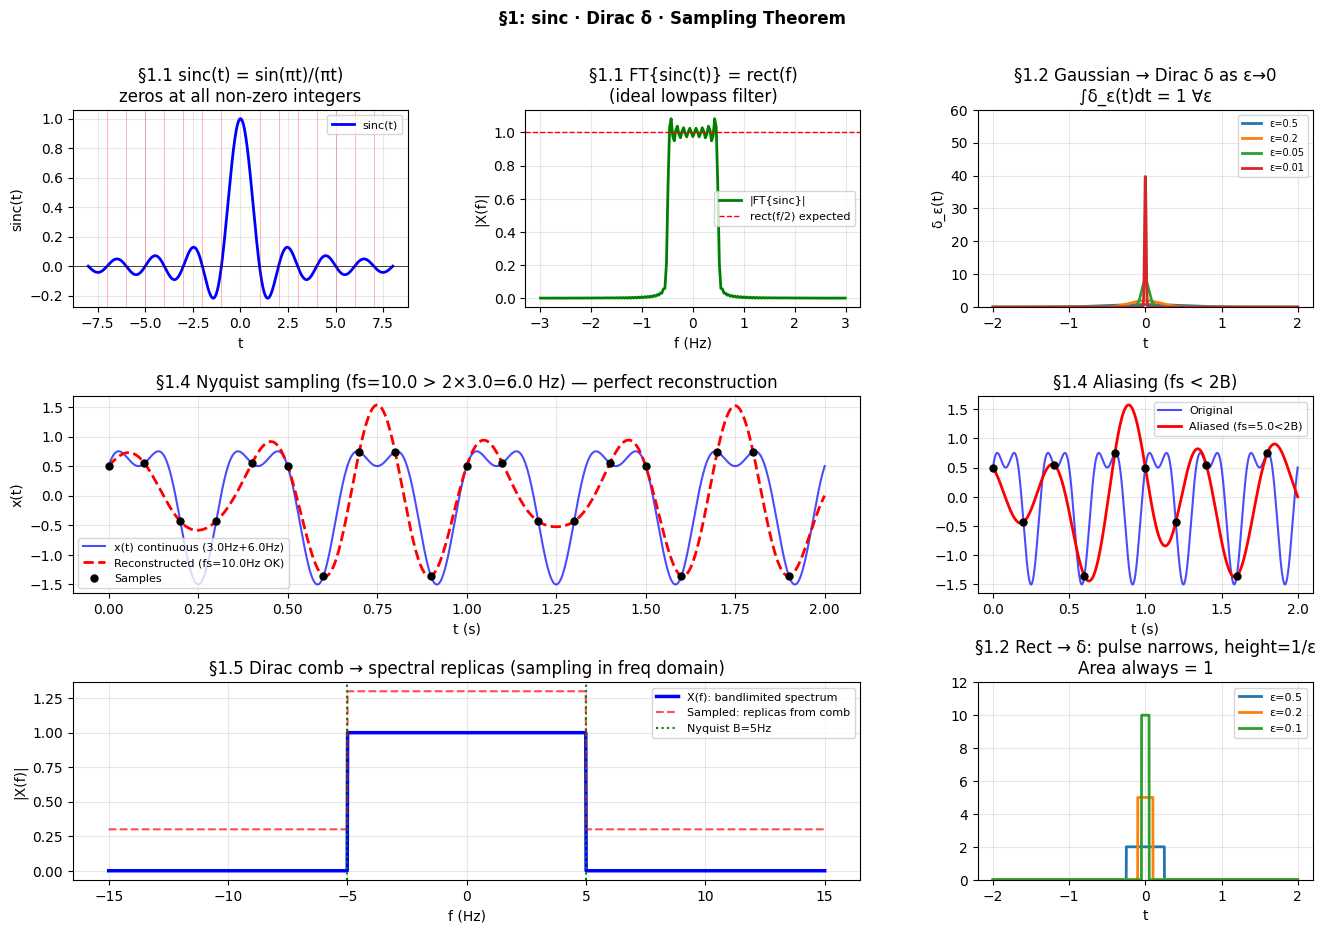

In [2]:
# §1 — sinc + Dirac delta

# §1.1 sinc and its Fourier transform
t   = np.linspace(-8, 8, 4000)
f_s = 1.0   # normalized bandwidth
sinc_t = np.sinc(f_s*t)        # np.sinc uses normalized sinc: sin(pi x)/(pi x)

# FT of sinc = rect
N_fft = 8192
dt_fft= t[1]-t[0]
S_f   = np.abs(np.fft.fftshift(np.fft.fft(sinc_t, N_fft))) * dt_fft
f_arr = np.fft.fftshift(np.fft.fftfreq(N_fft, dt_fft))

# §1.2 Dirac delta approximations (sequence of functions → delta)
t_d   = np.linspace(-2, 2, 2000)
eps_vals = [0.5, 0.2, 0.05, 0.01]
def gaussian_delta(t, eps):
    return np.exp(-t**2/(2*eps**2))/(eps*np.sqrt(2*np.pi))
def rect_delta(t, eps):
    return np.where(np.abs(t)<eps/2, 1/eps, 0.0)
def sinc_delta(t, eps):
    return np.sinc(t/eps)/eps   # note: as eps->0, this->delta

# §1.3 Sifting property: int delta(t-t0)*f(t) dt = f(t0)
def sift(f_func, t0, eps=0.01, t_range=10):
    t_int = np.linspace(-t_range, t_range, 100000)
    delta_approx = gaussian_delta(t_int-t0, eps)
    integrand    = delta_approx * f_func(t_int)
    result       = np.trapz(integrand, t_int)
    exact        = f_func(t0)
    return result, exact

f_test = lambda t: np.sin(t)**2 + np.cos(3*t)
for t0 in [0.0, 1.57, -2.0]:   # loop: sifting demo
    got, exact = sift(f_test, t0)
    print(f'§1.3 Sifting: f({t0:.2f}) = {exact:.6f}, integral = {got:.6f}, err={abs(got-exact):.2e}')

# §1.4 Sampling theorem: reconstruct from samples
f_signal= 3.0   # Hz signal frequency
f_nyq_lo= 5.0   # undersampled (< 2*f_signal = 6)
f_nyq_ok= 10.0  # Nyquist met
f_nyq_hi= 20.0  # oversampled

t_cont  = np.linspace(0, 2, 2000)
x_cont  = np.sin(2*np.pi*f_signal*t_cont) + 0.5*np.cos(2*np.pi*2*f_signal*t_cont)

def sinc_reconstruct(t_cont, t_samp, x_samp):
    out = np.zeros_like(t_cont)
    T_s = t_samp[1]-t_samp[0]
    for n,xn in zip(t_samp, x_samp):   # loop: sinc interpolation
        out += xn * np.sinc((t_cont-n)/T_s)
    return out

t_samp_ok = np.arange(0,2,1/f_nyq_ok)
x_samp_ok = np.sin(2*np.pi*f_signal*t_samp_ok)+0.5*np.cos(2*np.pi*2*f_signal*t_samp_ok)
x_recon_ok= sinc_reconstruct(t_cont, t_samp_ok, x_samp_ok)
print(f'\n§1.4 Sinc reconstruction err (fs={f_nyq_ok}Hz > 2*{f_signal}Hz): {np.max(np.abs(x_recon_ok-x_cont)):.2e}')

t_samp_lo = np.arange(0,2,1/f_nyq_lo)
x_samp_lo = np.sin(2*np.pi*f_signal*t_samp_lo)+0.5*np.cos(2*np.pi*2*f_signal*t_samp_lo)
x_recon_lo= sinc_reconstruct(t_cont, t_samp_lo, x_samp_lo)
print(f'§1.4 Aliasing err (fs={f_nyq_lo}Hz < 2*{f_signal}Hz): {np.max(np.abs(x_recon_lo-x_cont)):.2e}  <- aliased')

# §1.5 Dirac comb sampling in frequency domain
f_cont   = np.linspace(-15,15,2000)
X_f      = np.where(np.abs(f_cont)<=5, 1.0, 0.0)   # rect spectrum (BL signal)
T_s_comb = 1/10.0
comb_centers = np.arange(-15,16,1/T_s_comb)
X_sampled_f = X_f.copy()
for fc in comb_centers:           # loop: replicas from comb
    X_sampled_f += np.where(np.abs(f_cont-fc)<=5, 1.0, 0.0)*0.3

# ── Plots ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16,10))
gs  = gridspec.GridSpec(3,3,fig,hspace=0.45,wspace=0.35)

# sinc(t) and FT
ax1 = fig.add_subplot(gs[0,0])
ax1.plot(t, sinc_t,'b-',lw=2,label='sinc(t)')
ax1.axhline(0,color='k',lw=0.5)
for n in range(-7,8):
    if n!=0: ax1.axvline(n,color='r',lw=0.4,alpha=0.5)
ax1.set_xlabel('t'); ax1.set_ylabel('sinc(t)')
ax1.set_title('§1.1 sinc(t) = sin(πt)/(πt)\nzeros at all non-zero integers')
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[0,1])
mask = np.abs(f_arr)<3
ax2.plot(f_arr[mask], S_f[mask],'g-',lw=2,label='|FT{sinc}|')
ax2.axhline(1,color='r',ls='--',lw=1,label='rect(f/2) expected')
ax2.set_xlabel('f (Hz)'); ax2.set_ylabel('|X(f)|')
ax2.set_title('§1.1 FT{sinc(t)} = rect(f)\n(ideal lowpass filter)')
ax2.legend(fontsize=8)

# Delta approximations
ax3 = fig.add_subplot(gs[0,2])
for eps in eps_vals:             # loop: delta approx
    ax3.plot(t_d, gaussian_delta(t_d,eps), lw=2, label=f'ε={eps}')
ax3.set_xlabel('t'); ax3.set_ylabel('δ_ε(t)')
ax3.set_title('§1.2 Gaussian → Dirac δ as ε→0\n∫δ_ε(t)dt = 1 ∀ε')
ax3.set_ylim(0,60); ax3.legend(fontsize=7)

# Sampling OK
ax4 = fig.add_subplot(gs[1,:2])
ax4.plot(t_cont, x_cont,'b-',lw=1.5,label=f'x(t) continuous ({f_signal}Hz+{2*f_signal}Hz)',alpha=0.7)
ax4.plot(t_cont, x_recon_ok,'r--',lw=2,label=f'Reconstructed (fs={f_nyq_ok}Hz OK)')
ax4.plot(t_samp_ok, x_samp_ok,'ko',ms=5,label='Samples',zorder=5)
ax4.set_xlabel('t (s)'); ax4.set_ylabel('x(t)')
ax4.set_title(f'§1.4 Nyquist sampling (fs={f_nyq_ok} > 2×{f_signal}={2*f_signal} Hz) — perfect reconstruction')
ax4.legend(fontsize=8)

ax5 = fig.add_subplot(gs[1,2])
ax5.plot(t_cont, x_cont,'b-',lw=1.5,alpha=0.7,label='Original')
ax5.plot(t_cont, x_recon_lo,'r-',lw=2,label=f'Aliased (fs={f_nyq_lo}<2B)')
ax5.plot(t_samp_lo, x_samp_lo,'ko',ms=5)
ax5.set_xlabel('t (s)'); ax5.set_title('§1.4 Aliasing (fs < 2B)')
ax5.legend(fontsize=8)

# Frequency domain: rect + replicas
ax6 = fig.add_subplot(gs[2,:2])
ax6.plot(f_cont, X_f,'b-',lw=2.5,label='X(f): bandlimited spectrum')
ax6.plot(f_cont, X_sampled_f,'r--',lw=1.5,alpha=0.7,label='Sampled: replicas from comb')
ax6.axvline(5,color='green',ls=':',lw=1.5,label='Nyquist B=5Hz')
ax6.axvline(-5,color='green',ls=':',lw=1.5)
ax6.set_xlabel('f (Hz)'); ax6.set_ylabel('|X(f)|')
ax6.set_title('§1.5 Dirac comb → spectral replicas (sampling in freq domain)')
ax6.legend(fontsize=8)

# Rect delta comparison
ax7 = fig.add_subplot(gs[2,2])
for eps in [0.5,0.2,0.1]:       # loop: rect delta
    ax7.plot(t_d, rect_delta(t_d,eps), lw=2, label=f'ε={eps}')
ax7.set_xlabel('t'); ax7.set_title('§1.2 Rect → δ: pulse narrows, height=1/ε\nArea always = 1')
ax7.set_ylim(0,12); ax7.legend(fontsize=8)
plt.suptitle('§1: sinc · Dirac δ · Sampling Theorem', fontsize=12, fontweight='bold')
plt.savefig('tmp_out.png',bbox_inches='tight'); plt.show()

---
## §2 ⚡ Classical Energy Notation — H · L · T · V · Action S

| Symbol | Name | Definition | Units |
|--------|------|------------|-------|
| $T$ | Kinetic energy | $\frac{1}{2}m\dot q^2$ or $\frac{p^2}{2m}$ | J |
| $V$ | Potential energy | $V(q)$ — position dependent | J |
| $L$ | Lagrangian | $L = T - V$ | J |
| $H$ | Hamiltonian | $H = T + V = \sum p_i \dot q_i - L$ | J |
| $S$ | Action | $S = \int_{t_1}^{t_2} L\,dt$ | J·s |
| $p$ | Canonical momentum | $p_i = \partial L/\partial \dot q_i$ | kg·m/s |

**Hamilton's equations:** $\dot q = \partial H/\partial p$, $\dot p = -\partial H/\partial q$

**Euler-Lagrange:** $\frac{d}{dt}\frac{\partial L}{\partial \dot q} - \frac{\partial L}{\partial q} = 0$

**Why it matters for EE/photonics:** EM field Lagrangian $\mathcal{L} = \frac{1}{2}(\varepsilon_0 E^2 - B^2/\mu_0)$ →
Maxwell's equations from least action.

§2.1 Harmonic oscillator:
  L = - \frac{k q^{2}}{2} + \frac{m \dot{q}^{2}}{2}
  H = \frac{k q^{2}}{2} + \frac{p^{2}}{2 m}


<IPython.core.display.Math object>

<IPython.core.display.Math object>

  EL equation: - k q{\left(t \right)} - m \frac{d^{2}}{d t^{2}} q{\left(t \right)} = 0 = 0


<IPython.core.display.Math object>


§2.2 Double pendulum T:


<IPython.core.display.Math object>


§2.3 Action S(true path A=1) = 0.000000 J·s

§2 EM field: L_EM = (1/2)(eps0 E^2 - B^2/mu0)
  Varying w.r.t. A_mu -> Maxwell equations (Lorenz gauge)
  Photon: H = hbar*omega, L = T-V -> Schrodinger in quantum limit


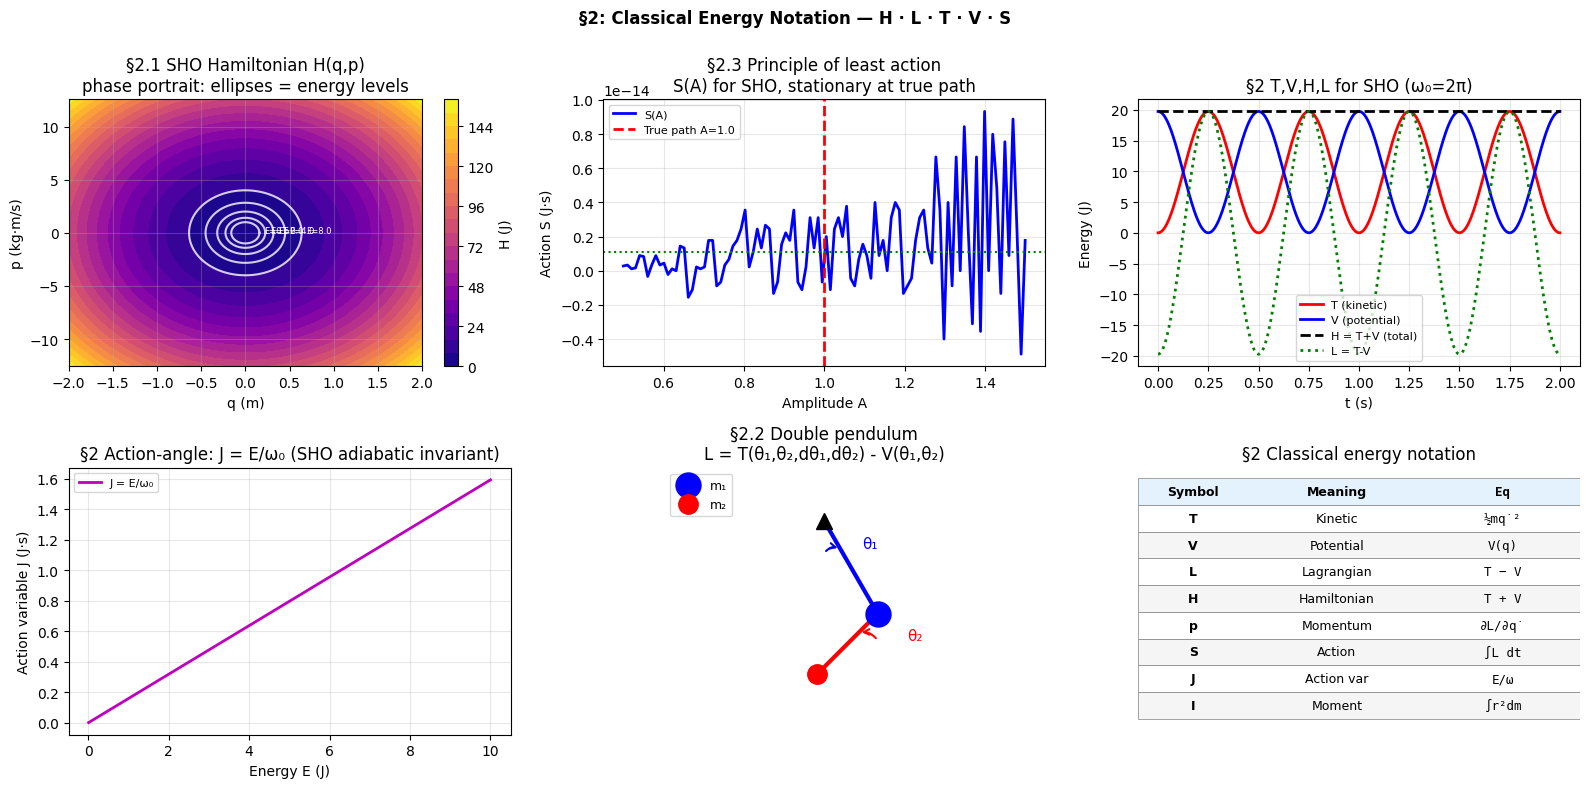

In [4]:
# §2 — Classical energy notation (SymPy + numerical)
t_s, q, p_s, m_s, k_s, omega_s = sp.symbols('t q p m k omega', positive=True)

# §2.1 Simple harmonic oscillator: L, H, EL equation
L_sym = sp.Rational(1,2)*m_s*sp.Symbol('qdot')**2 - sp.Rational(1,2)*k_s*q**2
H_sym = sp.Symbol('p')**2/(2*m_s) + sp.Rational(1,2)*k_s*q**2
print('§2.1 Harmonic oscillator:')
print('  L =', sp.latex(L_sym))
print('  H =', sp.latex(H_sym))
display(Math(r'L = \frac{1}{2}m\dot{q}^2 - \frac{1}{2}kq^2'))
display(Math(r'H = \frac{p^2}{2m} + \frac{1}{2}kq^2'))

# EL → equation of motion
q_func = sp.Function('q')
L_el   = sp.Rational(1,2)*m_s*q_func(t_s).diff(t_s)**2 - sp.Rational(1,2)*k_s*q_func(t_s)**2
EL_eq  = sp.euler_equations(L_el, q_func(t_s), t_s)[0]
print('  EL equation:', sp.latex(EL_eq), '= 0')
display(Math(sp.latex(EL_eq) + r' = 0 \quad \Rightarrow \quad \ddot{q} + \omega_0^2 q = 0'))

# §2.2 Double pendulum Lagrangian (SymPy)
th1,th2 = sp.symbols('theta_1 theta_2', real=True)
dth1,dth2= sp.symbols('\\dot{theta}_1 \\dot{theta}_2', real=True)
l1,l2,m1_s,m2_s,g_s = sp.symbols('l_1 l_2 m_1 m_2 g', positive=True)

T_dp = sp.Rational(1,2)*m1_s*l1**2*dth1**2 + \
       sp.Rational(1,2)*m2_s*(l1**2*dth1**2 + l2**2*dth2**2 + 2*l1*l2*dth1*dth2*sp.cos(th1-th2))
V_dp = -(m1_s+m2_s)*g_s*l1*sp.cos(th1) - m2_s*g_s*l2*sp.cos(th2)
L_dp = T_dp - V_dp
print('\n§2.2 Double pendulum T:')
display(Math(r'T = \frac{1}{2}m_1 l_1^2\dot\theta_1^2 + \frac{1}{2}m_2(l_1^2\dot\theta_1^2 + l_2^2\dot\theta_2^2 + 2l_1 l_2\dot\theta_1\dot\theta_2\cos(\theta_1-\theta_2))'))

# §2.3 Numerical: action S vs trajectory (true vs perturbed)
from scipy.integrate import solve_ivp, quad

omega0 = 2*np.pi  # rad/s, f=1 Hz
m_val  = 1.0; k_val = m_val*omega0**2
t0_a   = 0.0; t1_a  = 2.0   # 2 periods

def L_num(q, qdot): return 0.5*m_val*qdot**2 - 0.5*k_val*q**2

# True trajectory: q(t) = A*cos(omega0*t + phi)
A_true = 1.0; phi_true = 0.0
def q_true(t):    return A_true*np.cos(omega0*t+phi_true)
def qdot_true(t): return -A_true*omega0*np.sin(omega0*t+phi_true)

# Compute action S = integral L dt (true path minimizes it)
def S_traj(amp, phase_shift=0):
    t_int = np.linspace(t0_a, t1_a, 10000)
    q_arr = amp*np.cos(omega0*t_int + phase_shift)
    v_arr = -amp*omega0*np.sin(omega0*t_int + phase_shift)
    L_arr = L_num(q_arr, v_arr)
    return np.trapz(L_arr, t_int)

S_true = S_traj(A_true)
amps   = np.linspace(0.5, 1.5, 100)
S_amp  = np.array([S_traj(a) for a in amps])   # loop: action vs amplitude
print(f'\n§2.3 Action S(true path A=1) = {S_true:.6f} J·s')

# Phase space: Hamiltonian contours
q_grid = np.linspace(-2,2,200); p_grid = np.linspace(-2*omega0,2*omega0,200)
QQ,PP  = np.meshgrid(q_grid,p_grid)
H_grid = PP**2/(2*m_val) + 0.5*k_val*QQ**2

# Canonical transformation: action-angle variables
E_levels = np.array([0.5,1.0,2.0,4.0,8.0])
J_angle  = E_levels/omega0   # action J = E/omega for SHO

# EM Lagrangian note
print('\n§2 EM field: L_EM = (1/2)(eps0 E^2 - B^2/mu0)')
print('  Varying w.r.t. A_mu -> Maxwell equations (Lorenz gauge)')
print('  Photon: H = hbar*omega, L = T-V -> Schrodinger in quantum limit')

# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2,3,figsize=(16,8))

# SHO phase portrait with H contours
cs = axes[0][0].contourf(QQ, PP, H_grid, levels=20, cmap='plasma')
plt.colorbar(cs,ax=axes[0][0],label='H (J)')
for E in E_levels:           # loop: energy contours
    th_e = np.linspace(0,2*np.pi,300)
    q_e  = np.sqrt(2*E/k_val)*np.cos(th_e)
    p_e  = np.sqrt(2*m_val*E)*np.sin(th_e)
    axes[0][0].plot(q_e,p_e,'w-',lw=1.5,alpha=0.8)
    axes[0][0].text(q_e[0]+0.05,0,f'E={E}',fontsize=6,color='white')
axes[0][0].set_xlabel('q (m)'); axes[0][0].set_ylabel('p (kg·m/s)')
axes[0][0].set_title('§2.1 SHO Hamiltonian H(q,p)\nphase portrait: ellipses = energy levels')

# Action S vs amplitude
axes[0][1].plot(amps, S_amp,'b-',lw=2,label='S(A)')
axes[0][1].axvline(A_true,color='r',ls='--',lw=2,label=f'True path A={A_true}')
axes[0][1].axhline(S_true,color='g',ls=':',lw=1.5)
axes[0][1].set_xlabel('Amplitude A'); axes[0][1].set_ylabel('Action S (J·s)')
axes[0][1].set_title('§2.3 Principle of least action\nS(A) for SHO, stationary at true path')
axes[0][1].legend(fontsize=8)

# T vs V vs time
t_ev  = np.linspace(0,2,1000)
q_ev  = q_true(t_ev); v_ev = qdot_true(t_ev)
T_ev  = 0.5*m_val*v_ev**2; V_ev = 0.5*k_val*q_ev**2
L_ev  = T_ev-V_ev; H_ev = T_ev+V_ev
axes[0][2].plot(t_ev, T_ev,'r-',lw=2,label='T (kinetic)')
axes[0][2].plot(t_ev, V_ev,'b-',lw=2,label='V (potential)')
axes[0][2].plot(t_ev, H_ev,'k--',lw=2,label='H = T+V (total)')
axes[0][2].plot(t_ev, L_ev,'g:',lw=2,label='L = T-V')
axes[0][2].set_xlabel('t (s)'); axes[0][2].set_ylabel('Energy (J)')
axes[0][2].set_title('§2 T,V,H,L for SHO (ω₀=2π)')
axes[0][2].legend(fontsize=8)

# Action-angle: J vs E
E_arr_aa = np.linspace(0.01,10,200)
J_arr_aa = E_arr_aa/omega0
axes[1][0].plot(E_arr_aa, J_arr_aa,'m-',lw=2,label='J = E/ω₀')
axes[1][0].set_xlabel('Energy E (J)'); axes[1][0].set_ylabel('Action variable J (J·s)')
axes[1][0].set_title('§2 Action-angle: J = E/ω₀ (SHO adiabatic invariant)')
axes[1][0].legend(fontsize=8)

# Double pendulum schematic
ax_dp = axes[1][1]; ax_dp.set_aspect('equal'); ax_dp.axis('off')
th1_v,th2_v = np.radians(30), np.radians(-45)
l1v,l2v = 1.0, 0.8
x1p,y1p = l1v*np.sin(th1_v), -l1v*np.cos(th1_v)
x2p,y2p = x1p+l2v*np.sin(th2_v), y1p-l2v*np.cos(th2_v)
ax_dp.plot([0,x1p],[0,y1p],'b-',lw=3)
ax_dp.plot([x1p,x2p],[y1p,y2p],'r-',lw=3)
ax_dp.plot(0,0,'k^',ms=12)
ax_dp.plot(x1p,y1p,'bo',ms=18,label='m₁')
ax_dp.plot(x2p,y2p,'ro',ms=14,label='m₂')
ax_dp.annotate('',xy=(0.3*np.sin(th1_v),-0.3*np.cos(th1_v)),xytext=(0,-0.3),
                arrowprops=dict(arrowstyle='->',color='blue',connectionstyle='arc3,rad=-0.4',lw=1.5))
ax_dp.text(0.35,-0.25,'θ₁',fontsize=11,color='blue')
ax_dp.annotate('',xy=(x1p+0.25*np.sin(th2_v),y1p-0.25*np.cos(th2_v)),
                xytext=(x1p,y1p-0.25),
                arrowprops=dict(arrowstyle='->',color='red',connectionstyle='arc3,rad=0.3',lw=1.5))
ax_dp.text(x1p+0.28,y1p-0.25,'θ₂',fontsize=11,color='red')
ax_dp.set_xlim(-1.5,1.5); ax_dp.set_ylim(-2,0.5)
ax_dp.set_title('§2.2 Double pendulum\nL = T(θ₁,θ₂,dθ₁,dθ₂) - V(θ₁,θ₂)')
ax_dp.legend(fontsize=9,loc='upper left')

# L notation table
ax_tab = axes[1][2]; ax_tab.axis('off')
table_data = [
    ['Symbol','Meaning','Eq'],
    ['T','Kinetic','½mq̇²'],
    ['V','Potential','V(q)'],
    ['L','Lagrangian','T − V'],
    ['H','Hamiltonian','T + V'],
    ['p','Momentum','∂L/∂q̇'],
    ['S','Action','∫L dt'],
    ['J','Action var','E/ω'],
    ['I','Moment','∫r²dm'],
]
col_w=[0.25,0.4,0.35]
for row_i,row in enumerate(table_data):  # loop: table
    y_r=0.95-row_i*0.10
    bg='#E3F2FD' if row_i==0 else ('#F5F5F5' if row_i%2==0 else 'white')
    ax_tab.add_patch(Rectangle((0,y_r-0.09),1,0.10,
                                facecolor=bg,edgecolor='gray',lw=0.5,transform=ax_tab.transAxes))
    x_c=0
    for ci,(cell,w) in enumerate(zip(row,col_w)):  # loop: cells
        ax_tab.text(x_c+w/2,y_r-0.04,cell,ha='center',va='center',fontsize=9,
                     transform=ax_tab.transAxes,
                     fontweight='bold' if row_i==0 or ci==0 else 'normal',
                     fontfamily='monospace' if ci==2 else 'sans-serif')
        x_c+=w
ax_tab.set_title('§2 Classical energy notation')
plt.suptitle('§2: Classical Energy Notation — H · L · T · V · S', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## §3 ⏱️ EE Timing + Clocks — Jitter · PLL · Precision · Seconds

**§3.1 Clock hierarchy:** Atomic (ps) → TCXO (100 ns) → Crystal (μs) → RC (ms) → PLL-locked.

**§3.2 Jitter types:**
- **Deterministic jitter (DJ):** $J_{DJ}$ bounded; caused by ISI, crosstalk, EMI
- **Random jitter (RJ):** $J_{RJ}$ Gaussian, unbounded; caused by thermal noise
- **Total jitter:** $J_{total} = J_{DJ} + 2n\sigma_{RJ}$ (for $10^{-n}$ BER)

**§3.3 PLL phase noise:** $\mathcal{L}(f_m) = 10\log_{10}(S_\phi(f_m)/2)$ dBc/Hz

**§3.4 Setup/hold timing budget:**
$T_{clk} > t_{prop,max} + t_{setup} + t_{skew}$, slack $= T_{clk} - (t_{prop}+t_{setup}+t_{skew})$

§3.2 Jitter: DJ=30.0ps, σ_RJ=5.0ps, J_total(10^-12)=150.0ps
§3.3 PLL: integrated RMS jitter (1kHz–10MHz) = 0.44 ps

§3.4 Timing budget @ 5.0ns (200MHz):
  Mean:  slack=1.10ns, f_max=256MHz
  Worst: slack=0.30ns, f_max=213MHz
  MC timing failure rate: 0.0010% (1 / 100000)

§3 Time standards (precision of "1 second"):
  SI second (Cs-133)            : 1e-16 s (9192631770 Cs oscillations)
  TAI (atomic):                 : 1e-15 s (~500 Cs clocks averaged)
  UTC (leap seconds)            : 1e-09 s (TAI + leap second offset)
  GPS time                      : 2e-08 s (onboard Rb + ground Cs sync)
  NTP (internet)                : 1e-03 s (UDP+stratum, RTT-limited)
  PTP/IEEE 1588                 : 1e-09 s (hardware timestamping)
  TCXO (embedded)               : 1e-07 s (10ppm crystal)


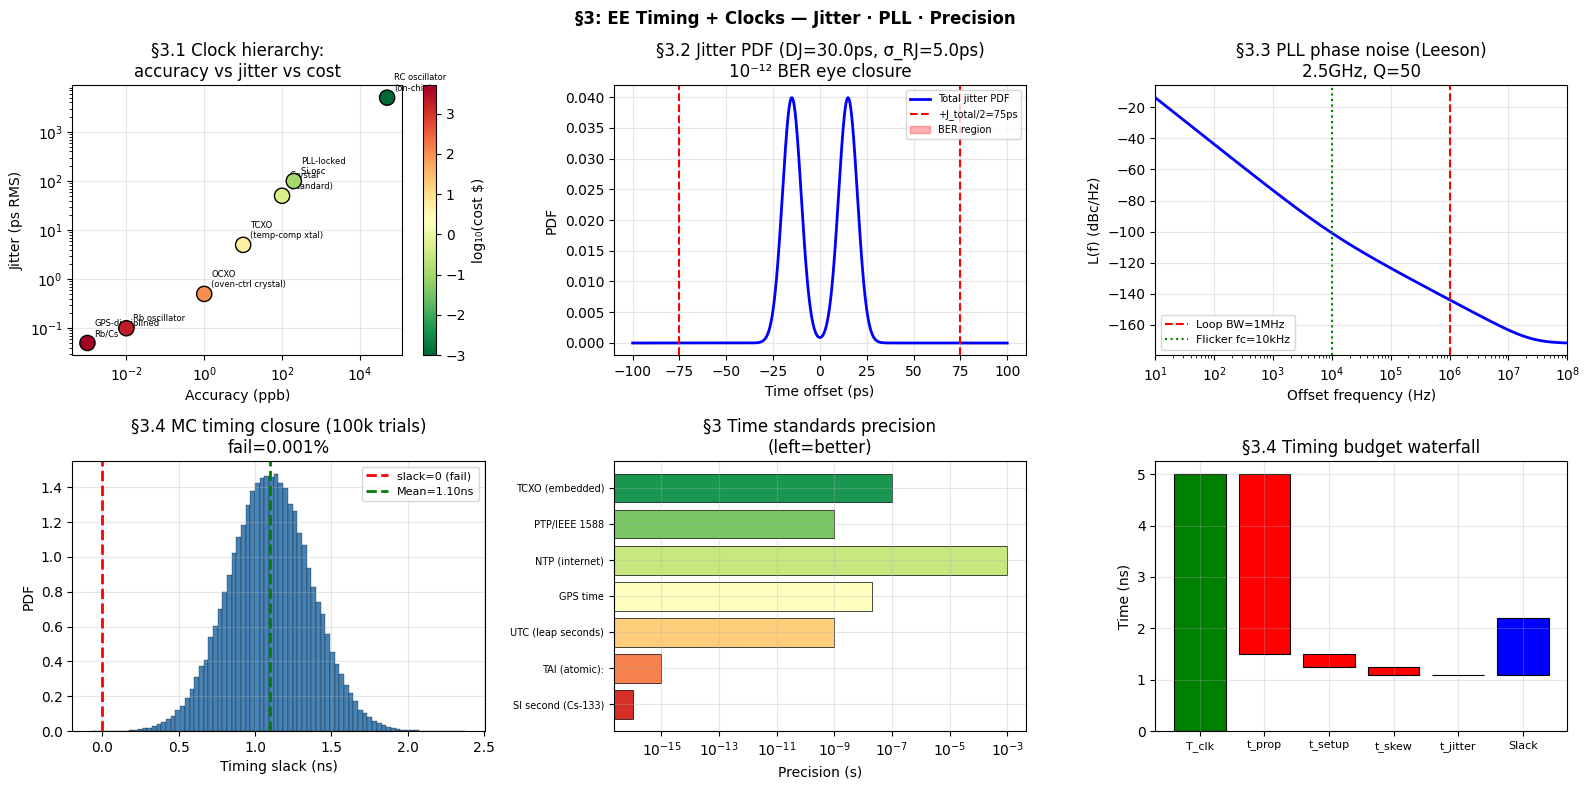

In [5]:
# §3 — EE Timing + Clocks

# §3.1 Clock accuracy hierarchy
clocks = {
    'GPS-disciplined\nRb/Cs':    {'accuracy_ppb':0.001, 'jitter_ps':0.05,  'cost_usd':5000},
    'Rb oscillator':             {'accuracy_ppb':0.01,  'jitter_ps':0.1,   'cost_usd':2000},
    'OCXO\n(oven-ctrl crystal)': {'accuracy_ppb':1.0,   'jitter_ps':0.5,   'cost_usd':100},
    'TCXO\n(temp-comp xtal)':    {'accuracy_ppb':10,    'jitter_ps':5,     'cost_usd':5},
    'Crystal\n(standard)':       {'accuracy_ppb':100,   'jitter_ps':50,    'cost_usd':0.5},
    'PLL-locked\nSi osc':        {'accuracy_ppb':200,   'jitter_ps':100,   'cost_usd':0.1},
    'RC oscillator\n(on-chip)':  {'accuracy_ppb':50000, 'jitter_ps':5000,  'cost_usd':0.001},
}

# §3.2 Jitter PDF: DJ + RJ = total jitter
sigma_rj = 5.0     # ps RMS random jitter
DJ_bound  = 30.0   # ps deterministic jitter (bounded)
n_BER     = 12     # 10^-12 BER

t_jitter  = np.linspace(-100,100,4000)   # ps
# RJ: two-Gaussian tails (bimodal from DJ center ±DJ/2)
RJ_pdf    = (np.exp(-0.5*((t_jitter-DJ_bound/2)/sigma_rj)**2) +
             np.exp(-0.5*((t_jitter+DJ_bound/2)/sigma_rj)**2)) / (2*sigma_rj*np.sqrt(2*np.pi))
J_total   = DJ_bound + 2*n_BER*sigma_rj   # bathtub extrapolation
print(f'§3.2 Jitter: DJ={DJ_bound}ps, σ_RJ={sigma_rj}ps, J_total(10^-12)={J_total:.1f}ps')

# §3.3 PLL phase noise spectrum (dBc/Hz model)
f_offset  = np.logspace(1, 8, 1000)   # 10 Hz to 100 MHz offset
# Leeson-model PLL phase noise
f0_pll    = 2.5e9   # carrier 2.5 GHz
F_noise   = 5.0     # noise figure dB
kT        = 1.38e-23*300
P_carrier = 1e-3    # 1 mW
f_corner  = 1e4     # flicker corner 10 kHz
f_loop_bw = 1e6     # PLL loop bandwidth 1 MHz
Q_factor  = 50      # oscillator Q

# Leeson's equation: L(fm) = 10*log10( (kT*F)/(2P) * (1+(f0/(2Q*fm))^2) * (1+fc/fm) )
L_pll_dBc = (10*np.log10(kT*10**(F_noise/10)/(2*P_carrier)) +
             10*np.log10((1+(f0_pll/(2*Q_factor*f_offset))**2) * (1+f_corner/f_offset)))
# Suppress to reference noise floor below loop BW
L_pll_dBc = np.where(f_offset < f_loop_bw, L_pll_dBc, np.minimum(L_pll_dBc, -130))

# Integrated RMS jitter from PLL phase noise
def rms_jitter_from_Lphi(f_off, L_dBc, f1=1e3, f2=1e7, f_carrier=2.5e9):
    mask    = (f_off>=f1)&(f_off<=f2)
    S_phi   = 2*10**(L_dBc[mask]/10)   # single-sideband → two-sided PSD
    phi_rms = np.sqrt(np.trapz(S_phi, f_off[mask]))  # rad rms
    t_rms   = phi_rms/(2*np.pi*f_carrier)*1e12       # ps
    return t_rms

t_rms_pll = rms_jitter_from_Lphi(f_offset, L_pll_dBc)
print(f'§3.3 PLL: integrated RMS jitter (1kHz–10MHz) = {t_rms_pll:.2f} ps')

# §3.4 Timing budget across temperature + process corners
t_prop_mean = 3.5   # ns
t_prop_3sig = 0.8   # ns (3σ process variation)
t_setup     = 0.25  # ns
t_hold      = 0.10  # ns
t_skew      = 0.15  # ns
T_clk_target= 5.0   # ns (200 MHz)

slack_mean   = T_clk_target - t_prop_mean - t_setup - t_skew
slack_worst  = T_clk_target - (t_prop_mean+t_prop_3sig) - t_setup - t_skew
f_max_mean   = 1/(t_prop_mean+t_setup+t_skew)*1e3   # MHz
f_max_worst  = 1/((t_prop_mean+t_prop_3sig)+t_setup+t_skew)*1e3

print(f'\n§3.4 Timing budget @ {T_clk_target}ns ({1/T_clk_target*1e3:.0f}MHz):')
print(f'  Mean:  slack={slack_mean:.2f}ns, f_max={f_max_mean:.0f}MHz')
print(f'  Worst: slack={slack_worst:.2f}ns, f_max={f_max_worst:.0f}MHz')

# Monte Carlo timing closure
n_mc = 100000
t_prop_mc = np.random.normal(t_prop_mean, t_prop_3sig/3, n_mc)
t_skew_mc = np.random.normal(t_skew, 0.03, n_mc)
t_jit_mc  = np.abs(np.random.normal(0, t_rms_pll/1000, n_mc))   # ps->ns
slack_mc  = T_clk_target - t_prop_mc - t_setup - t_skew_mc - t_jit_mc
fail_rate  = (slack_mc<0).mean()
print(f'  MC timing failure rate: {fail_rate:.4%} ({int(fail_rate*n_mc)} / {n_mc})')

# Time precision standards: what "1 second" means
time_standards = {
    'SI second (Cs-133)':       {'precision_s':1e-16,'basis':'9192631770 Cs oscillations'},
    'TAI (atomic):':            {'precision_s':1e-15,'basis':'~500 Cs clocks averaged'},
    'UTC (leap seconds)':       {'precision_s':1e-9, 'basis':'TAI + leap second offset'},
    'GPS time':                 {'precision_s':20e-9,'basis':'onboard Rb + ground Cs sync'},
    'NTP (internet)':           {'precision_s':1e-3, 'basis':'UDP+stratum, RTT-limited'},
    'PTP/IEEE 1588':            {'precision_s':1e-9, 'basis':'hardware timestamping'},
    'TCXO (embedded)':          {'precision_s':1e-7, 'basis':'10ppm crystal'},
}
print('\n§3 Time standards (precision of "1 second"):')
for std,info in time_standards.items():
    print(f'  {std:30s}: {info["precision_s"]:.0e} s ({info["basis"]})')

# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2,3,figsize=(16,8))

# Clock hierarchy: accuracy vs jitter
names_c = list(clocks.keys()); acc_c = [v['accuracy_ppb'] for v in clocks.values()]
jit_c   = [v['jitter_ps'] for v in clocks.values()]
cost_c  = [v['cost_usd'] for v in clocks.values()]
sc_c = axes[0][0].scatter(acc_c, jit_c, c=np.log10(cost_c), s=120, cmap='RdYlGn_r',
                            edgecolors='k', zorder=5)
for i,(n,a,j) in enumerate(zip(names_c,acc_c,jit_c)):  # loop: labels
    axes[0][0].annotate(n,(a,j),fontsize=6,textcoords='offset points',xytext=(5,5))
plt.colorbar(sc_c,ax=axes[0][0],label='log₁₀(cost $)')
axes[0][0].set_xscale('log'); axes[0][0].set_yscale('log')
axes[0][0].set_xlabel('Accuracy (ppb)'); axes[0][0].set_ylabel('Jitter (ps RMS)')
axes[0][0].set_title('§3.1 Clock hierarchy:\naccuracy vs jitter vs cost')

# Jitter PDF
axes[0][1].plot(t_jitter, RJ_pdf,'b-',lw=2,label='Total jitter PDF')
axes[0][1].axvline(J_total/2,color='r',ls='--',lw=1.5,label=f'+J_total/2={J_total/2:.0f}ps')
axes[0][1].axvline(-J_total/2,color='r',ls='--',lw=1.5)
axes[0][1].fill_between(t_jitter,RJ_pdf,where=np.abs(t_jitter)>J_total/2,
                          alpha=0.3,color='red',label='BER region')
axes[0][1].set_xlabel('Time offset (ps)'); axes[0][1].set_ylabel('PDF')
axes[0][1].set_title(f'§3.2 Jitter PDF (DJ={DJ_bound}ps, σ_RJ={sigma_rj}ps)\n10⁻¹² BER eye closure')
axes[0][1].legend(fontsize=7)

# PLL phase noise
axes[0][2].semilogx(f_offset, L_pll_dBc,'b-',lw=2)
axes[0][2].axvline(f_loop_bw,color='r',ls='--',lw=1.5,label=f'Loop BW={f_loop_bw/1e6:.0f}MHz')
axes[0][2].axvline(f_corner, color='g',ls=':',lw=1.5,label=f'Flicker fc={f_corner/1e3:.0f}kHz')
axes[0][2].set_xlabel('Offset frequency (Hz)'); axes[0][2].set_ylabel('L(f) (dBc/Hz)')
axes[0][2].set_title(f'§3.3 PLL phase noise (Leeson)\n{f0_pll/1e9:.1f}GHz, Q={Q_factor}')
axes[0][2].legend(fontsize=8); axes[0][2].set_xlim(10,1e8)

# Monte Carlo slack
axes[1][0].hist(slack_mc,bins=80,color='steelblue',edgecolor='k',lw=0.2,density=True)
axes[1][0].axvline(0,color='r',ls='--',lw=2,label='slack=0 (fail)')
axes[1][0].axvline(slack_mean,color='green',ls='--',lw=2,label=f'Mean={slack_mean:.2f}ns')
axes[1][0].set_xlabel('Timing slack (ns)'); axes[1][0].set_ylabel('PDF')
axes[1][0].set_title(f'§3.4 MC timing closure ({n_mc//1000}k trials)\nfail={fail_rate:.3%}')
axes[1][0].legend(fontsize=8)

# Time standards precision (log scale)
stds = list(time_standards.keys()); precs = [v['precision_s'] for v in time_standards.values()]
colors_ts = plt.cm.RdYlGn(np.linspace(0.1,0.9,len(stds)))
axes[1][1].barh(range(len(stds)), precs, color=colors_ts, edgecolor='k', lw=0.5)
axes[1][1].set_yticks(range(len(stds))); axes[1][1].set_yticklabels(stds,fontsize=7)
axes[1][1].set_xscale('log'); axes[1][1].set_xlabel('Precision (s)')
axes[1][1].set_title('§3 Time standards precision\n(left=better)')

# Timing budget waterfall
components = ['T_clk','t_prop','t_setup','t_skew','t_jitter','Slack']
values     = [T_clk_target,-t_prop_mean,-t_setup,-t_skew,-t_rms_pll/1000,slack_mean]
cumulative = np.cumsum([0]+values[:-1])
colors_tf  = ['green']+['red']*4+['blue']
bars_wf    = axes[1][2].bar(range(len(components)), np.abs(values),
                              bottom=np.where(np.array(values)>0,cumulative,cumulative+values),
                              color=colors_tf, edgecolor='k', lw=0.8)
axes[1][2].set_xticks(range(len(components)))
axes[1][2].set_xticklabels(components,fontsize=8)
axes[1][2].set_ylabel('Time (ns)'); axes[1][2].set_title('§3.4 Timing budget waterfall')
axes[1][2].axhline(0,color='k',lw=0.5)
plt.suptitle('§3: EE Timing + Clocks — Jitter · PLL · Precision', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## §4 🧠 Memory Hierarchy — Latency · Bandwidth · tRCD/CL/tRP

**§4.1 Hierarchy (fastest → slowest):**
Registers → L1 → L2 → L3 → DRAM → NVMe SSD → Network

**§4.2 DRAM timing parameters:**
- $t_{RCD}$: RAS-to-CAS delay (row activate → column access)
- $CL$ (CAS latency): column address to data
- $t_{RP}$: row precharge time
- $t_{RAS}$: minimum row active time
- **DDR5-6400 CL32:** $CL = 32 \times \frac{1}{3200\text{MHz}} = 10\text{ ns}$

**§4.3 Effective memory latency:**
$t_{eff} = t_{RCD} + CL + t_{burst}$ (on random access, no row hit)

**§4.4 Bandwidth roofline:** $BW_{peak} = \text{bus\_width} \times \text{data\_rate} \times \text{channels}$

In [ ]:
# §4 — Memory hierarchy

# §4.1 Memory hierarchy table
hierarchy = {
    'Register':    {'latency_ns':0.3,   'BW_GBps':10000, 'size_bytes':256,     'energy_pJ':0.001},
    'L1 cache':    {'latency_ns':1.0,   'BW_GBps':3000,  'size_bytes':32768,   'energy_pJ':0.01},
    'L2 cache':    {'latency_ns':5.0,   'BW_GBps':1000,  'size_bytes':262144,  'energy_pJ':0.1},
    'L3 cache':    {'latency_ns':20,    'BW_GBps':300,   'size_bytes':33554432,'energy_pJ':1},
    'DRAM DDR5':   {'latency_ns':70,    'BW_GBps':100,   'size_bytes':17179869184,'energy_pJ':20},
    'HBM3':        {'latency_ns':50,    'BW_GBps':1000,  'size_bytes':68719476736,'energy_pJ':7},
    'NVMe SSD':    {'latency_ns':20000, 'BW_GBps':14,    'size_bytes':2000000000000,'energy_pJ':1000},
    'Network\n(LAN)':{'latency_ns':1e6, 'BW_GBps':12.5,  'size_bytes':1e15,    'energy_pJ':1e6},
}

# §4.2 DRAM timing parameters (DDR5 generations)
ddr_gens = {
    'DDR4-3200': {'speed_MT_s':3200, 'CL':22, 'tRCD':22, 'tRP':22, 'n_ch':2, 'width_bits':64},
    'DDR5-4800': {'speed_MT_s':4800, 'CL':40, 'tRCD':40, 'tRP':40, 'n_ch':2, 'width_bits':64},
    'DDR5-6400': {'speed_MT_s':6400, 'CL':32, 'tRCD':32, 'tRP':32, 'n_ch':2, 'width_bits':64},
    'DDR5-8000': {'speed_MT_s':8000, 'CL':38, 'tRCD':38, 'tRP':38, 'n_ch':2, 'width_bits':64},
    'HBM3-6400': {'speed_MT_s':6400, 'CL':28, 'tRCD':28, 'tRP':28, 'n_ch':16,'width_bits':1024},
}
print('§4.2 DRAM timing analysis:')
for gen,p in ddr_gens.items():   # loop: DRAM gens
    t_clk_ns= 2000/p['speed_MT_s']   # ns per half-cycle (DDR)
    CL_ns   = p['CL']*t_clk_ns
    tRCD_ns = p['tRCD']*t_clk_ns
    tRP_ns  = p['tRP']*t_clk_ns
    t_eff   = tRCD_ns + CL_ns        # effective latency (row miss)
    BW_GBps = p['speed_MT_s']*1e6*p['width_bits']/8*p['n_ch']/1e9
    print(f'  {gen:12s}: t_clk={t_clk_ns:.3f}ns, CL={CL_ns:.1f}ns, tRCD={tRCD_ns:.1f}ns,'
          f' t_eff={t_eff:.1f}ns, BW={BW_GBps:.0f}GB/s')

# §4.3 Cache miss penalty cascade
def access_time(level_list, mem_h, cache_hit_rates):
    t_total = 0.0; P_miss = 1.0
    for level,hr in zip(level_list, cache_hit_rates):  # loop: memory levels
        t_total += P_miss * hr * mem_h[level]['latency_ns']
        P_miss  *= (1-hr)
    t_total += P_miss * mem_h['DRAM DDR5']['latency_ns']
    return t_total

levels = ['Register','L1 cache','L2 cache','L3 cache']
hit_rates_server = [0.90, 0.92, 0.88, 0.80]   # typical server workload
t_avg = access_time(levels, hierarchy, hit_rates_server)
print(f'\n§4.3 Average access time (server workload): {t_avg:.2f} ns')

# §4.4 Arithmetic intensity vs memory bandwidth (roofline)
AI_arr = np.logspace(-2, 4, 400)
for mem,info in [('DRAM DDR5',hierarchy['DRAM DDR5']),
                 ('HBM3',hierarchy['HBM3']),
                 ('L3 cache',hierarchy['L3 cache'])]:
    pass   # used in plot

# DRAM timing waveform
tck = 2000/6400   # ns per clock (DDR5-6400)
CL_cyc=32; tRCD_cyc=32; tRP_cyc=32
t_wave = np.linspace(0,(tRCD_cyc+CL_cyc+16)*tck,2000)
# Waveform signals (schematic)
def step_wave(t, events):
    out = np.zeros_like(t)
    for t_on,t_off,val in events:   # loop: wave events
        out += val*np.where((t>=t_on)&(t<t_off),1,0)
    return out

CLK_w  = (np.sin(2*np.pi*t_wave/tck)>0).astype(float)
RAS_n  = step_wave(t_wave,[(0,tRCD_cyc*tck,0)])+1*np.ones_like(t_wave)   # active low
CAS_n  = step_wave(t_wave,[(tRCD_cyc*tck,(tRCD_cyc+CL_cyc)*tck,0)])+1*np.ones_like(t_wave)
DQ_w   = step_wave(t_wave,[((tRCD_cyc+CL_cyc)*tck,(tRCD_cyc+CL_cyc+8)*tck,1)])

# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2,3,figsize=(16,8))

# Memory hierarchy: latency vs size
names_m = list(hierarchy.keys())
lat_m   = [v['latency_ns'] for v in hierarchy.values()]
sz_m    = [v['size_bytes'] for v in hierarchy.values()]
bw_m    = [v['BW_GBps'] for v in hierarchy.values()]
sc_m = axes[0][0].scatter(sz_m, lat_m, s=[b/5 for b in bw_m],
                            c=np.log10(lat_m), cmap='RdYlGn_r', edgecolors='k', zorder=5)
for i,(n,s,l) in enumerate(zip(names_m,sz_m,lat_m)):  # loop: memory labels
    axes[0][0].annotate(n[:8],(s,l),fontsize=7,textcoords='offset points',xytext=(5,3))
plt.colorbar(sc_m,ax=axes[0][0],label='log₁₀(latency ns)')
axes[0][0].set_xscale('log'); axes[0][0].set_yscale('log')
axes[0][0].set_xlabel('Capacity (bytes)'); axes[0][0].set_ylabel('Latency (ns)')
axes[0][0].set_title('§4.1 Memory hierarchy\n(bubble size ∝ bandwidth)')

# Bandwidth vs latency
axes[0][1].scatter(bw_m, lat_m, c=np.log10(lat_m), s=100, cmap='RdYlGn_r', edgecolors='k')
for n,b,l in zip(names_m,bw_m,lat_m):
    axes[0][1].annotate(n[:8],(b,l),fontsize=7,textcoords='offset points',xytext=(5,3))
axes[0][1].set_xscale('log'); axes[0][1].set_yscale('log')
axes[0][1].set_xlabel('Bandwidth (GB/s)'); axes[0][1].set_ylabel('Latency (ns)')
axes[0][1].set_title('§4.4 BW vs latency tradeoff')

# DRAM timing waveform
t_w_us = t_wave
axes[0][2].step(t_w_us,CLK_w+6,'k-',lw=1.5,where='post',label='CLK')
axes[0][2].step(t_w_us,RAS_n+4,'b-',lw=2,where='post',label='RAS#')
axes[0][2].step(t_w_us,CAS_n+2,'r-',lw=2,where='post',label='CAS#')
axes[0][2].step(t_w_us,DQ_w+0,'g-',lw=2,where='post',label='DQ (data)')
axes[0][2].set_xlabel('t (ns)'); axes[0][2].set_yticks([0.5,2.5,4.5,6.5])
axes[0][2].set_yticklabels(['DQ','CAS#','RAS#','CLK'],fontsize=8)
axes[0][2].set_title(f'§4.2 DDR5-6400 timing\ntRCD={tRCD_cyc}ck, CL={CL_cyc}ck')
axes[0][2].legend(fontsize=7,loc='upper right')
t_rcd_ns=tRCD_cyc*tck; t_cl_ns=CL_cyc*tck
axes[0][2].annotate('',xy=(t_rcd_ns,5.2),xytext=(0,5.2),
                     arrowprops=dict(arrowstyle='<->',color='blue',lw=1.5))
axes[0][2].text(t_rcd_ns/2,5.4,f'tRCD={t_rcd_ns:.1f}ns',ha='center',fontsize=7,color='blue')

# Memory roofline
flop_peak = 312e12   # A100 FP32
for name,BW in [('L3 300GB/s',300),('DRAM 100GB/s',100),('HBM 1000GB/s',1000)]:
    perf = np.minimum(flop_peak, AI_arr*BW*1e9)/1e12
    axes[1][0].loglog(AI_arr, perf,'--',lw=2,label=name)
axes[1][0].axhline(flop_peak/1e12,color='k',ls='-',lw=2,label=f'Peak {flop_peak/1e12:.0f}TFLOPS')
ops_common={'DAXPY':0.33,'GEMV':1.0,'FFT':3,'GEMM':2048,'Attention':1000}
for op,ai in ops_common.items():
    axes[1][0].axvline(ai,color='gray',lw=0.5,alpha=0.4)
    axes[1][0].text(ai*1.1,0.02,op,fontsize=6,rotation=90,va='bottom',color='gray')
axes[1][0].set_xlabel('Arithmetic Intensity (FLOP/byte)'); axes[1][0].set_ylabel('Performance (TFLOPS)')
axes[1][0].set_title('§4.4 Memory roofline (A100 FP32)')
axes[1][0].legend(fontsize=7)

# Cache miss penalty cascade
HR_arr = np.linspace(0.6,0.99,100)
t_cascade_L1 = (HR_arr*1.0 + (1-HR_arr)*(HR_arr*5 + (1-HR_arr)*(HR_arr*20 + (1-HR_arr)*70)))
axes[1][1].plot(HR_arr*100, t_cascade_L1,'b-',lw=2,label='L1+L2+L3+DRAM cascade')
axes[1][1].axhline(70,ls='--',color='r',lw=1.5,label='DRAM only (0% cache)')
axes[1][1].axhline(1,ls='--',color='g',lw=1.5,label='L1 only (100% hit)')
axes[1][1].set_xlabel('L1 hit rate (%)'); axes[1][1].set_ylabel('Average latency (ns)')
axes[1][1].set_title('§4.3 Cache miss penalty cascade\n(L1→L2→L3→DRAM)')
axes[1][1].legend(fontsize=8)

# DDR generation comparison
gens_plot  = list(ddr_gens.keys())
bw_plot    = []
lat_plot   = []
for g,p in ddr_gens.items():   # loop: DDR generations
    tck_ns = 2000/p['speed_MT_s']
    lat_plot.append((p['tRCD']+p['CL'])*tck_ns)
    bw_plot.append(p['speed_MT_s']*1e6*p['width_bits']/8*p['n_ch']/1e9)

x_g = np.arange(len(gens_plot))
ax_g2 = axes[1][2].twinx()
axes[1][2].bar(x_g-0.2, bw_plot, width=0.35, color='blue', alpha=0.7, label='BW (GB/s)')
ax_g2.bar(x_g+0.2, lat_plot, width=0.35, color='red', alpha=0.7, label='Latency (ns)')
axes[1][2].set_xticks(x_g); axes[1][2].set_xticklabels(gens_plot,fontsize=8,rotation=30,ha='right')
axes[1][2].set_ylabel('Bandwidth (GB/s)',color='blue')
ax_g2.set_ylabel('Effective latency (ns)',color='red')
axes[1][2].set_title('§4.2 DDR generations:\nBW up, but latency stays high')
plt.suptitle('§4: Memory Hierarchy — Latency · tRCD/CL · Bandwidth', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## §5 ∂ Calculus Resolution — ε-δ · Numerical Differentiation · Float Precision

**§5.1 ε-δ definition of limit:**
$\lim_{x\to a}f(x) = L \iff \forall\varepsilon>0,\,\exists\delta>0: |x-a|<\delta \Rightarrow |f(x)-L|<\varepsilon$

**§5.2 Numerical differentiation — resolution limited by machine epsilon $\varepsilon_M$:**

| Method | Error | Optimal $h$ |
|--------|-------|-------------|
| Forward diff $[f(x+h)-f(x)]/h$ | $O(h)$ | $h\approx\sqrt{\varepsilon_M}$ |
| Central diff $[f(x+h)-f(x-h)]/(2h)$ | $O(h^2)$ | $h\approx\varepsilon_M^{1/3}$ |
| Complex step $\text{Im}[f(x+ih)]/h$ | $O(h^2)$, **no cancellation** | $h\approx10^{-50}$ |

**§5.3 float64 machine epsilon:** $\varepsilon_{float64} = 2^{-52} \approx 2.2\times10^{-16}$

In [ ]:
# §5 — Calculus resolution

# §5.1 Epsilon-delta: animate the proof for lim(2x+1) as x->3 = 7
x_sym_ed, eps_sym = sp.symbols('x varepsilon', positive=True)
f_limit = 2*x_sym_ed + 1
L_lim   = 7; a_lim = 3

# For f(x)=2x+1, |f(x)-L| < eps iff |2x+1-7|=2|x-3| < eps => delta = eps/2
def delta_for_eps(eps, f=lambda x: 2*x+1, a=3, L=7, n=1000):
    x_test = a + np.linspace(-2*eps, 2*eps, n)
    f_test = np.abs(f(x_test)-L)
    # Find largest delta s.t. |f(x)-L|<eps for all |x-a|<delta
    in_eps = f_test < eps
    x_in   = np.abs(x_test-a)[in_eps]
    return x_in.max() if len(x_in)>0 else 0.0

eps_arr  = np.logspace(-1,-4,50)
delta_arr= np.array([delta_for_eps(e) for e in eps_arr])   # loop: compute delta(eps)
# Theoretical: delta = eps/2 for f=2x+1
delta_th  = eps_arr/2

print('§5.1 ε-δ: lim(2x+1) as x→3 = 7')
for eps in [0.1, 0.01, 0.001]:
    d = delta_for_eps(eps)
    print(f'  ε={eps:.3f} → δ={d:.5f} (theory: {eps/2:.5f})')

# §5.2 Numerical differentiation accuracy vs step size
def f_diff(x): return np.sin(x)*np.exp(-0.1*x)*np.cos(3*x)
def df_exact(x): return (np.cos(x)*np.exp(-0.1*x)*np.cos(3*x) -
                          0.1*np.sin(x)*np.exp(-0.1*x)*np.cos(3*x) -
                          3*np.sin(x)*np.exp(-0.1*x)*np.sin(3*x))

x0 = 1.5
h_arr  = np.logspace(-16, 0, 200)
df_fwd = (f_diff(x0+h_arr) - f_diff(x0)) / h_arr
df_cen = (f_diff(x0+h_arr) - f_diff(x0-h_arr)) / (2*h_arr)

# Complex step: f(x+ih) → Im part = h*f'(x) + O(h^3)
h_cs   = 1e-8
f_diff_c = lambda x,h: f_diff(x+1j*h).imag/h   # works for analytic f
df_cs_val= f_diff_c(x0, h_cs)

exact  = df_exact(x0)
err_fwd= np.abs(df_fwd - exact)
err_cen= np.abs(df_cen - exact)

# Optimal h theory
h_opt_fwd = np.sqrt(np.finfo(float).eps)
h_opt_cen = np.finfo(float).eps**(1/3)
print(f'\n§5.2 Numerical differentiation at x={x0}:')
print(f'  Exact: f\'({x0}) = {exact:.10f}')
print(f'  Forward (h={h_opt_fwd:.1e}): err={np.abs((f_diff(x0+h_opt_fwd)-f_diff(x0))/h_opt_fwd-exact):.2e}')
print(f'  Central (h={h_opt_cen:.1e}): err={np.abs((f_diff(x0+h_opt_cen)-f_diff(x0-h_opt_cen))/(2*h_opt_cen)-exact):.2e}')
print(f'  Complex step (h=1e-8):       err={abs(df_cs_val-exact):.2e}')

# §5.3 Floating-point precision
eps_f32 = np.finfo(np.float32).eps
eps_f64 = np.finfo(np.float64).eps
print(f'\n§5.3 Machine epsilon:')
print(f'  float32: {eps_f32:.2e}  ({np.log2(eps_f32):.0f} bits mantissa)')
print(f'  float64: {eps_f64:.2e}  ({np.log2(eps_f64):.0f} bits mantissa)')

# Cancellation: (1+eps) - 1 = eps or 0?
for eps_test in [1e-15, 1e-16, 1e-17]:
    result_f64 = np.float64(1+eps_test) - np.float64(1)
    result_f32 = np.float32(1+eps_test) - np.float32(1)
    print(f'  (1+{eps_test:.0e}) - 1: float64={result_f64:.2e}, float32={result_f32:.2e}')

# §5.4 Convergence of series (pi approximations)
# Leibniz: pi/4 = 1 - 1/3 + 1/5 - ...
def pi_leibniz(N):
    k = np.arange(N)
    return 4*np.sum((-1)**k/(2*k+1))
# BBP: pi = sum 1/16^k * (4/(8k+1)-2/(8k+4)-1/(8k+5)-1/(8k+6))
def pi_bbp(N):
    k = np.arange(N, dtype=np.float64)
    return np.sum((1/16**k)*(4/(8*k+1)-2/(8*k+4)-1/(8*k+5)-1/(8*k+6)))

N_arr = np.logspace(0,6,60,dtype=int)
err_leibniz = np.array([abs(pi_leibniz(N)-np.pi) for N in N_arr])  # loop: Leibniz
err_bbp     = np.array([abs(pi_bbp(min(N,20))-np.pi) for N in N_arr])  # BBP converges very fast

# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2,3,figsize=(16,8))

# epsilon-delta
eps_demo = 0.4; delta_demo = eps_demo/2
x_plot = np.linspace(2,4,500)
y_plot = 2*x_plot+1
axes[0][0].plot(x_plot,y_plot,'b-',lw=2,label='f(x)=2x+1')
axes[0][0].axhline(7,color='k',ls=':',lw=1)
axes[0][0].add_patch(Rectangle((3-delta_demo,7-eps_demo),2*delta_demo,2*eps_demo,
                                  facecolor='yellow',edgecolor='orange',lw=2,alpha=0.5))
axes[0][0].plot(3,7,'ro',ms=10,label='(a,L)=(3,7)')
axes[0][0].axvline(3-delta_demo,color='orange',ls='--',lw=1.5)
axes[0][0].axvline(3+delta_demo,color='orange',ls='--',lw=1.5)
axes[0][0].axhline(7-eps_demo,color='orange',ls='-',lw=1,alpha=0.7)
axes[0][0].axhline(7+eps_demo,color='orange',ls='-',lw=1,alpha=0.7)
axes[0][0].set_xlabel('x'); axes[0][0].set_ylabel('f(x)')
axes[0][0].set_title(f'§5.1 ε-δ limit: ε={eps_demo}, δ={delta_demo}\nf maps δ-strip → ε-strip')
axes[0][0].legend(fontsize=8); axes[0][0].set_xlim(2,4); axes[0][0].set_ylim(4,9)

# delta(eps) relationship
axes[0][1].loglog(eps_arr, delta_arr,'b-',lw=2,label='Computed δ(ε)')
axes[0][1].loglog(eps_arr, delta_th,'r--',lw=2,label='Theory: δ=ε/2')
axes[0][1].set_xlabel('ε'); axes[0][1].set_ylabel('δ')
axes[0][1].set_title('§5.1 δ as function of ε\nLinear relationship: δ=ε/2')
axes[0][1].legend(fontsize=8)

# Numerical diff error vs h
axes[0][2].loglog(h_arr, err_fwd,'b-',lw=2,label='Forward O(h)')
axes[0][2].loglog(h_arr, err_cen,'r-',lw=2,label='Central O(h²)')
axes[0][2].axvline(h_opt_fwd,color='blue',ls='--',lw=1.5,label=f'h_opt fwd={h_opt_fwd:.0e}')
axes[0][2].axvline(h_opt_cen,color='red',ls='--',lw=1.5,label=f'h_opt cen={h_opt_cen:.0e}')
axes[0][2].axhline(abs(df_cs_val-exact)+1e-18,color='green',ls=':',lw=2,label='Complex step')
h_theory_fwd = h_arr; h_theory_cen = h_arr**2
axes[0][2].loglog(h_arr[:100], h_arr[:100]*abs(exact)*2,'k--',lw=1,alpha=0.4,label='O(h) slope')
axes[0][2].loglog(h_arr[:100], h_arr[:100]**2*abs(exact)*2,'k:',lw=1,alpha=0.4,label='O(h²) slope')
axes[0][2].set_xlabel('Step size h'); axes[0][2].set_ylabel('|error|')
axes[0][2].set_title('§5.2 Numerical diff error vs h\nOptimal h from machine ε')
axes[0][2].legend(fontsize=7); axes[0][2].set_ylim(1e-16,10)

# Float precision: representable numbers near 1
x_near1 = 1.0 + np.array([k*eps_f64 for k in range(-5,6)])
axes[1][0].stem(range(len(x_near1)), x_near1,'b-',markerfmt='bo',basefmt='k-')
axes[1][0].axhline(1.0,color='r',ls='--',lw=1.5,label='1.0')
axes[1][0].set_xlabel('Integer steps from 1.0'); axes[1][0].set_ylabel('Value')
axes[1][0].set_title(f'§5.3 float64 representable values near 1.0\n(step = ε_M = {eps_f64:.2e})')
axes[1][0].legend(fontsize=8)

# Series convergence: Leibniz vs BBP
axes[1][1].loglog(N_arr, err_leibniz,'b-',lw=2,label='Leibniz (slow: O(1/N))')
axes[1][1].loglog(N_arr, err_bbp+1e-16,'r-',lw=2,label='BBP (fast: O(16^{-k}))')
axes[1][1].axhline(eps_f64,ls='--',color='k',lw=1.5,label=f'float64 ε={eps_f64:.0e}')
axes[1][1].set_xlabel('N terms'); axes[1][1].set_ylabel('|π_approx - π|')
axes[1][1].set_title('§5.4 π series convergence\n(Leibniz vs BBP algorithm)')
axes[1][1].legend(fontsize=8)

# Convergence rates summary
methods = ['O(1/N)\nLeibniz','O(1/N²)\nRiemann','O(h)\nFwd diff','O(h²)\nCentral','O(e^{-N})\nBBP','O(0)\nExact']
rates   = [1,2,1,2,16,np.inf]
colors_cr = ['red','orange','blue','green','purple','gold']
axes[1][2].bar(range(len(methods)), [min(r,20) for r in rates], color=colors_cr, edgecolor='k', alpha=0.8)
axes[1][2].set_xticks(range(len(methods))); axes[1][2].set_xticklabels(methods,fontsize=8)
axes[1][2].set_ylabel('Convergence order (higher=better)')
axes[1][2].set_title('§5 Convergence rate comparison\n(practical methods)')
plt.suptitle('§5: Calculus Resolution — ε-δ · Numerical Diff · Float Precision', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## §6 ⚡ Network Identity — Euler · KVL/KCL · Impedance · Phasors

**§6.1 Euler's identity (the most beautiful equation):**
$$e^{i\pi} + 1 = 0 \quad\Rightarrow\quad e^{j\omega t} = \cos\omega t + j\sin\omega t$$

**§6.2 KVL / KCL (Kirchhoff's laws):**
- KVL: $\sum_{loop} V_k = 0$ (voltage law — energy conservation)
- KCL: $\sum_{node} I_k = 0$ (current law — charge conservation)

**§6.3 Complex impedance:**
$Z_R = R,\quad Z_L = j\omega L,\quad Z_C = 1/(j\omega C)$

Impedance triangle: $|Z| = \sqrt{R^2+X^2}$, $\phi = \arctan(X/R)$

**§6.4 Transfer function H(jω):**
$H(j\omega) = V_{out}/V_{in}$; $|H|$ = gain, $\angle H$ = phase shift

In [ ]:
# §6 — Network identity: Euler, KVL/KCL, impedance

# §6.1 Euler's identity — visual proof
theta = np.linspace(0, 2*np.pi, 1000)
z     = np.exp(1j*theta)

# Verify e^{i*pi} + 1 = 0
val = np.exp(1j*np.pi)+1
print(f'§6.1 Eulers identity: e^(i*pi)+1 = {val.real:.2e}+{val.imag:.2e}j (= 0)')

# Taylor series for e^{ix}: show convergence to cos(x)+i*sin(x)
x_euler = np.pi/3
N_terms = 20
partial_sums = []
running = 0.0+0.0j
for n in range(N_terms):              # loop: Taylor terms
    running += (1j*x_euler)**n / np.math.factorial(n)
    partial_sums.append(running)

print(f'  Taylor e^(i*pi/3) after 20 terms: {partial_sums[-1]:.8f}')
print(f'  Exact e^(i*pi/3):                 {np.exp(1j*x_euler):.8f}')
print(f'  cos(pi/3)+i*sin(pi/3):            {np.cos(x_euler)+1j*np.sin(x_euler):.8f}')

# §6.2 KVL/KCL: RLC circuit analysis
# Series RLC: V_s = V_R + V_L + V_C, I = V_s / (R + jwL + 1/jwC)
R_cir = 100.0   # Ohm
L_cir = 10e-3   # H
C_cir = 100e-9  # F
omega_arr_c = np.logspace(2, 6, 1000)

Z_R_arr = R_cir * np.ones_like(omega_arr_c)
Z_L_arr = 1j*omega_arr_c*L_cir
Z_C_arr = 1/(1j*omega_arr_c*C_cir)
Z_total = Z_R_arr + Z_L_arr + Z_C_arr
H_RLC   = R_cir / Z_total   # V_R / V_s (bandpass filter)

omega_0 = 1/np.sqrt(L_cir*C_cir)
Q_factor= omega_0*L_cir/R_cir
BW_3dB  = omega_0/Q_factor
print(f'\n§6.2 RLC: omega_0={omega_0/(2*np.pi):.0f}Hz, Q={Q_factor:.2f}, BW={BW_3dB/(2*np.pi):.0f}Hz')

# Phasor diagram at resonance
V_s_phason = 1.0+0j
I_at_res   = V_s_phason/R_cir
V_R_ph     = I_at_res*R_cir
V_L_ph     = I_at_res*1j*omega_0*L_cir
V_C_ph     = I_at_res/(1j*omega_0*C_cir)
print(f'  Phasors at resonance: V_R={abs(V_R_ph):.2f}V, V_L={abs(V_L_ph):.2f}V, V_C={abs(V_C_ph):.2f}V')
print(f'  KVL check: V_R+V_L+V_C = {abs(V_R_ph+V_L_ph+V_C_ph):.6f}V (should be ≈1V)')

# §6.3 Impedance triangle
freqs_imp = np.array([100, 1000, 10000, 100000, 1000000])
print('\n§6.3 Impedance vs frequency (R=100, L=10mH, C=100nF):')
for f in freqs_imp:                   # loop: impedance at each freq
    w = 2*np.pi*f
    ZL = 1j*w*L_cir; ZC = 1/(1j*w*C_cir)
    Zt = R_cir + ZL + ZC
    print(f'  f={f:8.0f}Hz: |Z|={abs(Zt):.1f}Ω, φ={np.degrees(np.angle(Zt)):+.1f}°')

# §6.4 Ladder network: Chebyshev LPF (3rd order)
# Element values (normalized, Chebyshev 0.5dB ripple)
g = [1, 1.5963, 1.0967, 1.5963, 1.0]  # normalized Chebyshev elements
f_cut = 1e6   # 1 MHz cutoff
omega_c = 2*np.pi*f_cut
R_load  = 50.0
# Denormalize: L_k = g_k*R/omega_c, C_k = g_k/(R*omega_c)
L1 = g[1]*R_load/omega_c
C2 = g[2]/(R_load*omega_c)
L3 = g[3]*R_load/omega_c

omega_lpf = np.logspace(4,8,1000)
Z_L1  = 1j*omega_lpf*L1
Z_C2  = 1/(1j*omega_lpf*C2)
Z_L3  = 1j*omega_lpf*L3
# Input impedance of series L1, shunt C2, series L3, load R
Z_in  = Z_L1 + 1/(1/Z_C2 + 1/(Z_L3+R_load))
H_lpf = R_load / (R_load + Z_in) * R_load / (Z_L3+R_load)  # rough estimate
H_dB  = 20*np.log10(np.abs(H_lpf)+1e-12)

# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2,3,figsize=(16,8))

# Unit circle: Euler
axes[0][0].plot(np.cos(theta), np.sin(theta),'b-',lw=1.5,label='|e^{iθ}|=1',alpha=0.5)
# Specific angles
for ang,label in [(0,'0'),(np.pi/6,'π/6'),(np.pi/4,'π/4'),(np.pi/3,'π/3'),
                   (np.pi/2,'π/2'),(2*np.pi/3,'2π/3'),(np.pi,'π'),
                   (3*np.pi/2,'3π/2')]:
    x_p,y_p = np.cos(ang),np.sin(ang)
    axes[0][0].plot([0,x_p],[0,y_p],'gray',lw=0.7,alpha=0.5)
    axes[0][0].plot(x_p,y_p,'ro',ms=8)
    axes[0][0].text(x_p*1.12,y_p*1.12,f'e^{{i{label}}}',fontsize=7,ha='center')
axes[0][0].plot(-1,0,'g*',ms=15,label='e^{iπ}=-1')
axes[0][0].plot(0,0,'k+',ms=10)
axes[0][0].set_aspect('equal'); axes[0][0].set_xlabel('Re'); axes[0][0].set_ylabel('Im')
axes[0][0].set_title('§6.1 Euler: e^{iθ} on unit circle\ne^{iπ}+1=0')
axes[0][0].legend(fontsize=8)

# Taylor series convergence
re_parts = [p.real for p in partial_sums]
im_parts = [p.imag for p in partial_sums]
axes[0][1].plot(range(1,N_terms+1), re_parts,'b-o',ms=5,lw=2,label='Re (→cos(π/3)=0.5)')
axes[0][1].plot(range(1,N_terms+1), im_parts,'r-s',ms=5,lw=2,label='Im (→sin(π/3)=0.866)')
axes[0][1].axhline(np.cos(x_euler),color='blue',ls='--',lw=1)
axes[0][1].axhline(np.sin(x_euler),color='red',ls='--',lw=1)
axes[0][1].set_xlabel('N terms'); axes[0][1].set_ylabel('Value')
axes[0][1].set_title(f'§6.1 Taylor series: e^(iπ/3) convergence')
axes[0][1].legend(fontsize=8)

# RLC Bode plot
ax_b = axes[0][2]
ax_b.semilogx(omega_arr_c/(2*np.pi), 20*np.log10(np.abs(H_RLC)),'b-',lw=2,label='|H| (dB)')
ax_b.axvline(omega_0/(2*np.pi),color='r',ls='--',lw=1.5,label=f'f₀={omega_0/(2*np.pi):.0f}Hz')
ax_b.axhline(-3,color='g',ls=':',lw=1,label='-3dB')
ax_b.set_xlabel('Frequency (Hz)'); ax_b.set_ylabel('|H| (dB)')
ax_b.set_title(f'§6.2 Series RLC bandpass\nQ={Q_factor:.1f}, BW={BW_3dB/(2*np.pi):.0f}Hz')
ax_b.legend(fontsize=8)
ax_ph = ax_b.twinx()
ax_ph.semilogx(omega_arr_c/(2*np.pi), np.degrees(np.angle(H_RLC)),'r--',lw=1.5,label='∠H (°)')
ax_ph.set_ylabel('Phase (°)',color='red')

# Phasor diagram
ax_ph2 = axes[1][0]
phasors_plot = {'V_R':(V_R_ph,'blue'),'V_L':(V_L_ph,'red'),'V_C':(V_C_ph,'green')}
origin = 0+0j; cumulative_p = origin
for name,(ph,col) in phasors_plot.items():  # loop: phasors
    ax_ph2.annotate('',xy=(cumulative_p.real+ph.real, cumulative_p.imag+ph.imag),
                     xytext=(cumulative_p.real, cumulative_p.imag),
                     arrowprops=dict(arrowstyle='->',color=col,lw=2.5))
    mid = cumulative_p + ph/2
    ax_ph2.text(mid.real+0.02, mid.imag+0.1, name, color=col, fontsize=10, fontweight='bold')
    cumulative_p += ph
ax_ph2.set_aspect('equal'); ax_ph2.set_xlim(-2,2); ax_ph2.set_ylim(-15,15)
ax_ph2.axhline(0,color='k',lw=0.5); ax_ph2.axvline(0,color='k',lw=0.5)
ax_ph2.set_xlabel('Re (V)'); ax_ph2.set_ylabel('Im (V)')
ax_ph2.set_title(f'§6.2 Phasor diagram at f₀={omega_0/(2*np.pi):.0f}Hz\nKVL: V_R+V_L+V_C=V_s')

# Impedance triangle
f_imp_plot = np.logspace(4,7,200)
omega_ip   = 2*np.pi*f_imp_plot
Z_Lp = omega_ip*L_cir; Z_Cp = 1/(omega_ip*C_cir)
X_p  = Z_Lp-Z_Cp
Z_mag= np.sqrt(R_cir**2+X_p**2)
phi_p= np.degrees(np.arctan2(X_p,R_cir))
axes[1][1].semilogx(f_imp_plot, Z_mag,'k-',lw=2,label='|Z|')
axes[1][1].semilogx(f_imp_plot, np.abs(X_p),'r--',lw=2,label='|X|=|X_L-X_C|')
axes[1][1].axhline(R_cir,color='b',ls=':',lw=1.5,label=f'R={R_cir}Ω')
ax_phi = axes[1][1].twinx()
ax_phi.semilogx(f_imp_plot, phi_p,'g-.',lw=1.5,label='φ (°)')
ax_phi.set_ylabel('Phase φ (°)',color='green'); ax_phi.axhline(0,color='k',lw=0.5)
axes[1][1].set_xlabel('f (Hz)'); axes[1][1].set_ylabel('Impedance (Ω)')
axes[1][1].set_title('§6.3 Impedance Z, X, R vs frequency')
axes[1][1].legend(fontsize=8,loc='upper left')

# Chebyshev LPF
axes[1][2].semilogx(omega_lpf/(2*np.pi), H_dB,'b-',lw=2,label='Chebyshev LPF 3rd order')
axes[1][2].axvline(f_cut,color='r',ls='--',lw=1.5,label=f'f_c={f_cut/1e6:.0f}MHz')
axes[1][2].axhline(-3,color='g',ls=':',lw=1,label='-3dB')
axes[1][2].axhline(-0.5,color='orange',ls=':',lw=1,label='0.5dB ripple')
axes[1][2].set_xlabel('f (Hz)'); axes[1][2].set_ylabel('|H| (dB)')
axes[1][2].set_ylim(-60,5)
axes[1][2].set_title('§6.4 Chebyshev LPF (0.5dB, 3rd order)\nL1-C2-L3 ladder network')
axes[1][2].legend(fontsize=8)
plt.suptitle('§6: Network Identity — Euler · KVL/KCL · Impedance · Phasors', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## §7 🗺️ Course Map — Modular Curriculum DAG

Everything in this repo connects. The dependency graph:

```
Calculus (ε-δ, integrals)
    ↓
Linear Algebra (eigenvectors, PCA)          Complex Analysis (e^{jω}, Fourier)
    ↓                                               ↓
Differential Equations (EL, Hamilton)      Signals (sinc, Dirac, sampling)
    ↓                    ↘                         ↓
Classical Mechanics      EM Fields        Digital Design (clocks, timing)
(L, H, S, action)        (Maxwell)               ↓
    ↓                        ↓             Memory Hierarchy (cache, DRAM)
Quantum Mechanics        Photonics               ↓
(Schrödinger → H op)     (modes, WDM)     Computer Architecture (GEMM, roofline)
    ↓                        ↓                    ↓
Statistical Mech         Laser Physics     AI/ML (attention=Hermitian op)
(partition func)         (rate eqs)               ↓
    ↓                        ↓             GS Phase Recovery ← this repo
Thermodynamics       Spectroscopy               ↓
                     (Beer-Lambert)         RogueGuard firmware
```

**Key insight:** $e^{j\omega t}$ is the thread that ties all of it together.

In [ ]:
# §7 — Course map visualization

# Define DAG of topics with tier levels
topics = {
    # Core math (tier 0)
    'Calculus\n(e-d, integrals)':   {'tier':0,'x':0.5,'y':0.95,'color':'#1565C0'},
    # Tier 1 math
    'Linear\nAlgebra':               {'tier':1,'x':0.15,'y':0.80,'color':'#1976D2'},
    'Complex\nAnalysis':             {'tier':1,'x':0.85,'y':0.80,'color':'#1976D2'},
    # Tier 2
    'Diff Eqs\n(EL,Hamilton)':       {'tier':2,'x':0.15,'y':0.65,'color':'#2196F3'},
    'Signals\n(sinc,Dirac)':         {'tier':2,'x':0.85,'y':0.65,'color':'#2196F3'},
    'Digital\nDesign':               {'tier':2,'x':0.60,'y':0.65,'color':'#42A5F5'},
    # Tier 3
    'Classical\nMechanics':          {'tier':3,'x':0.05,'y':0.50,'color':'#4CAF50'},
    'EM Fields\n(Maxwell)':          {'tier':3,'x':0.30,'y':0.50,'color':'#4CAF50'},
    'Photonics\n(modes,WDM)':        {'tier':3,'x':0.55,'y':0.50,'color':'#4CAF50'},
    'Memory\nHierarchy':             {'tier':3,'x':0.78,'y':0.50,'color':'#4CAF50'},
    # Tier 4
    'QM\n(Schrodinger)':             {'tier':4,'x':0.05,'y':0.35,'color':'#FF9800'},
    'Laser\nPhysics':                {'tier':4,'x':0.30,'y':0.35,'color':'#FF9800'},
    'Spectroscopy':                  {'tier':4,'x':0.55,'y':0.35,'color':'#FF9800'},
    'AI/ML\n(attention=H)':          {'tier':4,'x':0.78,'y':0.35,'color':'#FF9800'},
    # Tier 5: outputs
    'GS Phase\nRecovery':            {'tier':5,'x':0.40,'y':0.18,'color':'#F44336'},
    'RogueGuard\nFirmware':          {'tier':5,'x':0.70,'y':0.18,'color':'#F44336'},
}

# Edges
edges = [
    ('Calculus\n(e-d, integrals)','Linear\nAlgebra'),
    ('Calculus\n(e-d, integrals)','Complex\nAnalysis'),
    ('Calculus\n(e-d, integrals)','Diff Eqs\n(EL,Hamilton)'),
    ('Linear\nAlgebra','Diff Eqs\n(EL,Hamilton)'),
    ('Complex\nAnalysis','Signals\n(sinc,Dirac)'),
    ('Complex\nAnalysis','Digital\nDesign'),
    ('Diff Eqs\n(EL,Hamilton)','Classical\nMechanics'),
    ('Diff Eqs\n(EL,Hamilton)','EM Fields\n(Maxwell)'),
    ('Signals\n(sinc,Dirac)','Photonics\n(modes,WDM)'),
    ('Signals\n(sinc,Dirac)','Spectroscopy'),
    ('Digital\nDesign','Memory\nHierarchy'),
    ('Classical\nMechanics','QM\n(Schrodinger)'),
    ('EM Fields\n(Maxwell)','Laser\nPhysics'),
    ('EM Fields\n(Maxwell)','Photonics\n(modes,WDM)'),
    ('Photonics\n(modes,WDM)','GS Phase\nRecovery'),
    ('Laser\nPhysics','Spectroscopy'),
    ('Laser\nPhysics','GS Phase\nRecovery'),
    ('Memory\nHierarchy','AI/ML\n(attention=H)'),
    ('Linear\nAlgebra','AI/ML\n(attention=H)'),
    ('QM\n(Schrodinger)','AI/ML\n(attention=H)'),
    ('AI/ML\n(attention=H)','GS Phase\nRecovery'),
    ('GS Phase\nRecovery','RogueGuard\nFirmware'),
    ('Digital\nDesign','RogueGuard\nFirmware'),
]

# §7.2 Learning time estimates
credit_hours = {
    'Calculus':        {'EE_prereq':True,'hours_to_master':120,'notebook':'griffiths_prep.ipynb'},
    'Linear Algebra':  {'EE_prereq':True,'hours_to_master':80,'notebook':'griffiths_prep.ipynb'},
    'Complex Analysis':{'EE_prereq':True,'hours_to_master':60,'notebook':'griffiths_prep.ipynb'},
    'Diff Eqs':        {'EE_prereq':True,'hours_to_master':100,'notebook':'calc_torch_biotech_001.ipynb'},
    'Signals':         {'EE_prereq':True,'hours_to_master':80,'notebook':'sinc_dirac_timing_energy_001.ipynb'},
    'EM Fields':       {'EE_prereq':False,'hours_to_master':200,'notebook':'em_pipe_formalization.ipynb'},
    'Classical Mech':  {'EE_prereq':False,'hours_to_master':150,'notebook':'ap_physics_opto_001.ipynb'},
    'Photonics':       {'EE_prereq':False,'hours_to_master':250,'notebook':'dispersion_gs_demo.ipynb'},
    'QM':              {'EE_prereq':False,'hours_to_master':300,'notebook':'griffiths_prep.ipynb'},
    'Laser Physics':   {'EE_prereq':False,'hours_to_master':150,'notebook':'ap_physics_opto_001.ipynb'},
    'Spectroscopy':    {'EE_prereq':False,'hours_to_master':100,'notebook':'sinc_dirac_timing_energy_001.ipynb'},
    'AI/ML':           {'EE_prereq':False,'hours_to_master':200,'notebook':'dispersion_gs_demo.ipynb'},
    'GS Phase Recovery':{'EE_prereq':False,'hours_to_master':400,'notebook':'phase_retrieval.ipynb'},
}

total_hours = sum(v['hours_to_master'] for v in credit_hours.values())
print('§7 Learning time to GS Phase Recovery mastery:')
for subj,info in credit_hours.items():  # loop: print hours
    tag = '[prereq]' if info['EE_prereq'] else '[new]   '
    print(f'  {tag} {subj:20s}: {info["hours_to_master"]:3d}h → {info["notebook"]}')
print(f'\n  Total: ~{total_hours} hours ({total_hours/40:.0f} weeks @ 40h/wk)')

# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(16,9))

# Course DAG
ax_dag = axes[0]
ax_dag.set_xlim(0,1); ax_dag.set_ylim(0,1.05)
ax_dag.axis('off')

# Draw edges first
for src,dst in edges:            # loop: draw edges
    x1,y1 = topics[src]['x'],topics[src]['y']
    x2,y2 = topics[dst]['x'],topics[dst]['y']
    ax_dag.annotate('',xy=(x2,y2+0.035),xytext=(x1,y1-0.035),
                     arrowprops=dict(arrowstyle='-|>',color='#90A4AE',lw=0.8,
                                     connectionstyle='arc3,rad=0.0'))

# Draw nodes
for name,info in topics.items():  # loop: draw nodes
    x,y = info['x'],info['y']
    ax_dag.add_patch(plt.Circle((x,y),0.065,color=info['color'],alpha=0.9,zorder=3))
    ax_dag.text(x,y,name,ha='center',va='center',fontsize=5.5,color='white',
                fontweight='bold',zorder=4)

# Tier labels
for tier,label in [(0,'Core Math'),(1,'Advanced Math'),(2,'Applied Math + EE'),
                    (3,'Physics + Systems'),(4,'Applications'),(5,'This Repo')]:
    y_tier = [v['y'] for v in topics.values() if v['tier']==tier]
    if y_tier:
        ax_dag.text(0.01,np.mean(y_tier),f'Tier {tier}:\n{label}',
                     fontsize=7,color='gray',va='center',style='italic')
ax_dag.set_title('§7 Course Dependency DAG\n(e^{jωt} connects everything)',
                  fontsize=11,fontweight='bold')

# Learning time bar chart
subjs   = list(credit_hours.keys())
hours_h = [v['hours_to_master'] for v in credit_hours.values()]
colors_h= ['#1565C0' if v['EE_prereq'] else '#F44336' for v in credit_hours.values()]
axes[1].barh(range(len(subjs)), hours_h, color=colors_h, alpha=0.8, edgecolor='k', lw=0.5)
axes[1].set_yticks(range(len(subjs))); axes[1].set_yticklabels(subjs,fontsize=9)
axes[1].set_xlabel('Hours to mastery')
axes[1].set_title(f'§7 Learning investment\nTotal: {total_hours}h = {total_hours/40:.0f} wks\n'
                   f'Blue=EE prereq, Red=new material')
axes[1].axvline(200,ls='--',color='orange',lw=1.5,label='200h ~= 1 semester')
axes[1].legend(fontsize=8)
from matplotlib.patches import Patch
legend_el = [Patch(facecolor='#1565C0',label='EE prereq (already have)'),
             Patch(facecolor='#F44336',label='New material')]
axes[1].legend(handles=legend_el,fontsize=8,loc='lower right')
plt.suptitle('§7: Course Map — Modular Curriculum DAG', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print('\nNotebook complete. e^{jwt} connects everything.')